## **Supervised Model III – XGBoost (Improved)**

Key changes from XGBoost_improved3:
1. build_unsupervised_scores now *picks the best tool from each space* (latent vs handcrafted feature space). From the latent space it takes SVD reconstruction error (MSE and MAE) — the only latent features that were positively correlated. From the handcrafted feature space it takes Isolation Forest and Mahalanobis — which had AUCs of 0.692 and 0.751 in your first diagnostics (XGBoost_improved2), better than anything the latent space produced for those methods. All the anti-correlated features (latent IF, latent Mahalanobis, latent distance) are gone.

The blend at test time now uses only SVD recon MSE as the standalone score, since it's the single most reliable signal, with a conservative BLEND_ALPHA = 0.15.

In [1]:
results = []

In [2]:
import matplotlib.pyplot as plt
import zipfile, warnings
import xgboost as xgb
import pandas as pd
import numpy as np
import optuna
from scipy.stats import entropy
from scipy.spatial.distance import mahalanobis
from scipy.sparse import csr_matrix
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import TruncatedSVD, NMF

warnings.filterwarnings('ignore')

TOTAL_ITEMS = 1000
RATING_RANGE = range(6)
N_SVD_COMPONENTS = 50

/Users/tori/Documents/OFFICES/SCHOOL/Y3S2/Machine_Learning_421_SMU/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### **Data Loading**

In [3]:
# ── I/O helpers ──────────────────────────────────────────────────────

def load_npz(path: str) -> tuple[pd.DataFrame, pd.DataFrame | None]:
    data = np.load(path)
    XX = pd.DataFrame(data["X"], columns=["user", "item", "rating"])
    yy = None
    if "y" in data:
        yy = pd.DataFrame(data["y"], columns=["user", "label"])
    return XX, yy


def combine_labeled_data(
    *npz_paths: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    all_X, all_y = [], []
    for path in npz_paths:
        data = np.load(path)
        all_X.append(pd.DataFrame(data["X"], columns=["user", "item", "rating"]))
        all_y.append(pd.DataFrame(data["y"], columns=["user", "label"]))

    XX = pd.concat(all_X, ignore_index=True)
    yy = pd.concat(all_y, ignore_index=True).drop_duplicates(subset="user", keep="first")

    n_anom = int(yy["label"].sum())
    print(f"Combined {len(npz_paths)} files")
    print(f"{yy.shape[0]} users ({n_anom} anomalous, {yy.shape[0] - n_anom} normal), {XX.shape[0]} interactions")
    return XX, yy

In [4]:
# ── Sparse matrix builder ────────────────────────────────────────────

def build_user_item_matrix(XX: pd.DataFrame, user_ids: np.ndarray):
    """Build a sparse user×item rating matrix.
    
    Returns:
        mat: sparse CSR matrix (n_users × TOTAL_ITEMS)
        uid_to_row: dict mapping user_id → row index
    """
    uid_to_row = {uid: i for i, uid in enumerate(user_ids)}

    # Vectorised — avoid iterrows on 400k+ rows
    mask = XX["user"].isin(uid_to_row)
    sub = XX.loc[mask]
    rows = sub["user"].map(uid_to_row).values
    cols = sub["item"].values.astype(int)
    vals = sub["rating"].values.astype(float)

    mat = csr_matrix((vals, (rows, cols)), shape=(len(user_ids), TOTAL_ITEMS))
    return mat, uid_to_row

In [5]:
# ── Original hand-crafted features (kept from your notebook) ────────

def compute_item_stats(XX_train: pd.DataFrame) -> dict:
    item_avg = XX_train.groupby("item")["rating"].mean().rename("item_avg_rating")
    item_pop = XX_train.groupby("item")["user"].count().rename("item_popularity")
    return {"item_avg_rating": item_avg, "item_popularity": item_pop}


def build_handcrafted_features(
    XX: pd.DataFrame,
    item_stats: dict,
    total_items: int = TOTAL_ITEMS,
) -> pd.DataFrame:
    """Original 24 features — unchanged from your notebook."""
    item_avg = item_stats["item_avg_rating"]
    item_pop = item_stats["item_popularity"]

    stats = XX.groupby("user")["rating"].agg(
        rating_mean="mean", rating_std="std", rating_median="median",
        rating_min="min", rating_max="max", rating_count="count",
    )
    stats["rating_std"] = stats["rating_std"].fillna(0)
    stats["rating_range"] = stats["rating_max"] - stats["rating_min"]

    rdist = XX.groupby(["user", "rating"]).size().unstack(fill_value=0)
    rdist = rdist.reindex(columns=RATING_RANGE, fill_value=0)
    rprops = rdist.div(rdist.sum(axis=1), axis=0)
    rprops.columns = [f"prop_rating_{i}" for i in RATING_RANGE]
    stats["rating_entropy"] = rprops.apply(
        lambda row: entropy(row.values[row.values > 0]), axis=1
    )
    stats = stats.join(rprops)
    stats["prop_extreme"] = rprops["prop_rating_0"] + rprops["prop_rating_5"]

    stats["unique_items_rated"] = XX.groupby("user")["item"].nunique()
    stats["item_coverage_ratio"] = stats["unique_items_rated"] / total_items

    XX_pop = XX.merge(item_pop, left_on="item", right_index=True, how="left")
    XX_pop["item_popularity"] = XX_pop["item_popularity"].fillna(0)
    pop_f = XX_pop.groupby("user")["item_popularity"].agg(
        avg_item_popularity="mean", std_item_popularity="std",
    )
    pop_f["std_item_popularity"] = pop_f["std_item_popularity"].fillna(0)
    stats = stats.join(pop_f)

    XX_dev = XX.merge(item_avg, left_on="item", right_index=True, how="left")
    global_train_mean = item_avg.mean()
    XX_dev["item_avg_rating"] = XX_dev["item_avg_rating"].fillna(global_train_mean)
    XX_dev["deviation"] = XX_dev["rating"] - XX_dev["item_avg_rating"]
    dev_f = XX_dev.groupby("user")["deviation"].agg(
        mean_deviation="mean", std_deviation="std",
        abs_mean_deviation=lambda x: np.mean(np.abs(x)),
    )
    dev_f["std_deviation"] = dev_f["std_deviation"].fillna(0)
    stats = stats.join(dev_f)

    iqf = XX_dev.groupby("user")["item_avg_rating"].agg(
        avg_item_avg_rating="mean", std_item_avg_rating="std",
    )
    iqf["std_item_avg_rating"] = iqf["std_item_avg_rating"].fillna(0)
    stats = stats.join(iqf)

    return stats.reset_index()

In [ ]:
# ── Structural features ─────────────────────────────────────────

def build_structural_features(XX: pd.DataFrame) -> pd.DataFrame:
    """Features that capture the *shape* of a user's behaviour,
    not just summary statistics.  These generalise across anomaly types."""

    feats = pd.DataFrame({"user": XX["user"].unique()})

    # ── Global rating distribution (for KL divergence) ────────────────
    global_dist = XX["rating"].value_counts(normalize=True).reindex(RATING_RANGE, fill_value=0).values
    global_dist = np.clip(global_dist, 1e-10, None)  # avoid log(0)

    def user_kl(group):
        user_dist = group["rating"].value_counts(normalize=True).reindex(RATING_RANGE, fill_value=0).values
        user_dist = np.clip(user_dist, 1e-10, None)
        return entropy(user_dist, global_dist)

    kl_df = XX.groupby("user").apply(user_kl).rename("kl_div_from_global")
    feats = feats.merge(kl_df, on="user", how="left")

    # ── Gini coefficient of item selection ────────────────────────────
    def gini_coeff(group):
        counts = group["item"].value_counts().values.astype(float)
        if len(counts) <= 1:
            return 0.0
        counts = np.sort(counts)
        n = len(counts)
        index = np.arange(1, n + 1)
        return (2.0 * np.sum(index * counts) / (n * np.sum(counts))) - (n + 1.0) / n

    gini_df = XX.groupby("user").apply(gini_coeff).rename("item_gini")
    feats = feats.merge(gini_df, on="user", how="left")

    # ── Rating "flatness" — how uniform is the rating vector? ────────
    def rating_flatness(group):
        ratings = group["rating"].values
        if len(ratings) <= 1:
            return 0.0
        # proportion of ratings equal to the mode
        vals, counts = np.unique(ratings, return_counts=True)
        return counts.max() / len(ratings)

    flat_df = XX.groupby("user").apply(rating_flatness).rename("rating_mode_frac")
    feats = feats.merge(flat_df, on="user", how="left")

    # ── Rating skewness & kurtosis ───────────────────────────────────
    skew_df = XX.groupby("user")["rating"].skew().rename("rating_skew").fillna(0)
    kurt_df = XX.groupby("user")["rating"].apply(
        lambda x: x.kurtosis() if len(x) >= 4 else 0.0
    ).rename("rating_kurtosis")
    feats = feats.merge(skew_df, on="user", how="left")
    feats = feats.merge(kurt_df, on="user", how="left")

    # ── Item overlap with popular items ──────────────────────────────
    top_items = set(XX["item"].value_counts().head(100).index)
    def top_item_frac(group):
        user_items = set(group["item"].values)
        return len(user_items & top_items) / max(len(user_items), 1)

    top_df = XX.groupby("user").apply(top_item_frac).rename("frac_top100_items")
    feats = feats.merge(top_df, on="user", how="left")

    # ── Ratings-per-item ratio (detects multi-rating anomalies) ─────
    rpi = XX.groupby("user").apply(
        lambda g: len(g) / g["item"].nunique()
    ).rename("ratings_per_item")
    feats = feats.merge(rpi, on="user", how="left")

    return feats

In [7]:
# ── (SVD + unsupervised scoring merged into build_unsupervised_scores) ─
pass


In [8]:
# ── Unsupervised scores: curated from both latent + handcrafted space ──
#
# Latent-space diagnostics revealed:
#   - IF, Mahalanobis, latent_dist are ANTI-CORRELATED (AUC < 0.5)
#     → anomalies sit CLOSER to centroid than normals (hyper-normal)
#   - SVD recon MSE works (0.765) — anomalies are in the right
#     neighbourhood but their ratings are internally inconsistent
#   - Handcrafted-space scores were better (IF=0.692, Maha=0.751)
#
# Strategy: use SVD recon error from latent space + handcrafted-space
# IF/Mahalanobis. Drop all distance-from-centroid features.

def build_unsupervised_scores(
    XX_ref: pd.DataFrame,
    XX_target: pd.DataFrame,
    target_users: np.ndarray,
    ref_normal_users: np.ndarray,
    X_handcrafted_ref: np.ndarray,
    X_handcrafted_target: np.ndarray,
    ref_labels: np.ndarray,
    n_components: int = N_SVD_COMPONENTS,
) -> tuple[np.ndarray, TruncatedSVD]:
    """Compute curated unsupervised features.

    Returns (scores_array, svd_model) where scores_array has columns:
      [svd_recon_mse, svd_recon_mae, iso_handcrafted, maha_handcrafted]
    """
    # ─── A) SVD reconstruction error (latent space, normal-only fit) ───
    XX_normal = XX_ref[XX_ref["user"].isin(ref_normal_users)]
    normal_uids = XX_normal["user"].unique()
    normal_mat, _ = build_user_item_matrix(XX_normal, normal_uids)

    n_comp = min(n_components, min(normal_mat.shape) - 1)
    svd = TruncatedSVD(n_components=n_comp, random_state=42)
    svd.fit(normal_mat)

    target_mat, _ = build_user_item_matrix(XX_target, target_users)
    latent = svd.transform(target_mat)
    reconstructed = latent @ svd.components_

    target_dense = target_mat.toarray()
    mask = (target_dense != 0).astype(float)
    diff = (target_dense - reconstructed) * mask
    n_rated = np.maximum(np.sum(mask, axis=1), 1)

    recon_mse = np.sum(diff ** 2, axis=1) / n_rated
    recon_mae = np.sum(np.abs(diff), axis=1) / n_rated

    # ─── B) IF + Mahalanobis on HANDCRAFTED features (normal-only fit) ─
    X_fit = X_handcrafted_ref[ref_labels == 0]

    iso = IsolationForest(
        n_estimators=500, contamination="auto", random_state=42, n_jobs=-1
    )
    iso.fit(X_fit)
    iso_scores = -iso.score_samples(X_handcrafted_target)

    try:
        mu = X_fit.mean(axis=0)
        cov = np.cov(X_fit, rowvar=False)
        cov += np.eye(cov.shape[0]) * 1e-6
        cov_inv = np.linalg.inv(cov)
        maha_scores = np.array([
            mahalanobis(x, mu, cov_inv) for x in X_handcrafted_target
        ])
    except Exception:
        mu = X_fit.mean(axis=0)
        maha_scores = np.linalg.norm(X_handcrafted_target - mu, axis=1)

    scores = np.column_stack([recon_mse, recon_mae, iso_scores, maha_scores])
    return scores, svd


UNSUP_COLS = [
    "svd_recon_mse", "svd_recon_mae",
    "iso_handcrafted", "maha_handcrafted",
]


In [9]:
# ── Combined feature pipeline ────────────────────────────────────────

def build_all_features(
    XX: pd.DataFrame,
    item_stats: dict,
) -> pd.DataFrame:
    """Merge handcrafted + structural features for a set of users.
    SVD and unsupervised scores are added separately (they need ref/target split).
    """
    hc = build_handcrafted_features(XX, item_stats)
    st = build_structural_features(XX)
    merged = hc.merge(st, on="user", how="left")
    return merged

In [ ]:
# ── Fold feature builder ──────────────────────────────────────────────

def make_fold_features(XX_raw, yy_raw, train_users, val_users):
    XX_tr  = XX_raw[XX_raw["user"].isin(train_users)].copy()
    XX_val = XX_raw[XX_raw["user"].isin(val_users)].copy()
    yy_tr  = yy_raw[yy_raw["user"].isin(train_users)].copy()
    yy_val = yy_raw[yy_raw["user"].isin(val_users)].copy()

    normal_train_users = yy_tr[yy_tr["label"] == 0]["user"].values
    item_stats_tr = compute_item_stats(XX_tr)

    # Handcrafted + structural features
    feats_tr  = build_all_features(XX_tr, item_stats_tr).merge(yy_tr, on="user")
    feats_val = build_all_features(XX_val, item_stats_tr).merge(yy_val, on="user")

    hc_cols = [c for c in feats_tr.columns if c not in ["user", "label"]]

    # Scale handcrafted features first (needed as input for IF/Maha)
    scaler_fold = RobustScaler()
    X_tr_hc_s = scaler_fold.fit_transform(feats_tr[hc_cols].values)
    X_val_hc_s = scaler_fold.transform(feats_val[hc_cols].values)

    y_tr_labels = feats_tr["label"].values

    # Unsupervised: SVD recon (latent) + IF/Maha (handcrafted)
    unsup_tr, svd_model = build_unsupervised_scores(
        XX_ref=XX_tr, XX_target=XX_tr,
        target_users=feats_tr["user"].values,
        ref_normal_users=normal_train_users,
        X_handcrafted_ref=X_tr_hc_s,
        X_handcrafted_target=X_tr_hc_s,
        ref_labels=y_tr_labels,
    )
    unsup_val, _ = build_unsupervised_scores(
        XX_ref=XX_tr, XX_target=XX_val,
        target_users=feats_val["user"].values,
        ref_normal_users=normal_train_users,
        X_handcrafted_ref=X_tr_hc_s,
        X_handcrafted_target=X_val_hc_s,
        ref_labels=y_tr_labels,
    )

    # Combine: handcrafted (scaled) + unsupervised scores
    X_tr_final  = np.hstack([X_tr_hc_s, unsup_tr])
    X_val_final = np.hstack([X_val_hc_s, unsup_val])
    feature_cols_all = hc_cols + UNSUP_COLS

    return (
        X_tr_final, feats_tr["label"].values,
        X_val_final, feats_val["label"].values,
        item_stats_tr, feature_cols_all, scaler_fold, svd_model,
        normal_train_users,
    )


In [11]:
# ── Evaluation helper ────────────────────────────────────────────────

def codabench_metrics(test_labels, scores, model_name, verbose=False):
    test_labels = np.asarray(test_labels).astype(int)
    scores = np.asarray(scores).astype(float)
    preds = (scores >= 0.5).astype(int)
    metrics = {
        "model": model_name,
        "AUC": roc_auc_score(test_labels, scores),
        "Precision": precision_score(test_labels, preds, zero_division=0),
        "Recall": recall_score(test_labels, preds, zero_division=0),
        "F1": f1_score(test_labels, preds, zero_division=0),
        "threshold": 0.5,
    }
    if verbose:
        print(f"{model_name} (Codabench t=0.5)")
        for k in ["AUC", "Precision", "Recall", "F1"]:
            print(f"# {k+':':12s} {metrics[k]:.4f}")
    return metrics

In [12]:
# Phase 3 data loading
XX_all, yy_all = combine_labeled_data(
    "data/training_batch_with_labels.npz",
    "data/first_batch_with_labels.npz",
    "data/second_batch_with_labels.npz",
)

Combined 3 files
3060 users (260 anomalous, 2800 normal), 479433 interactions


In [13]:
# Build full feature set for Optuna
item_stats_full = compute_item_stats(XX_all)
full_train_df = build_all_features(XX_all, item_stats_full).merge(yy_all, on="user")

normal_users_all = yy_all[yy_all["label"] == 0]["user"].values
hc_cols = [c for c in full_train_df.columns if c not in ["user", "label"]]

scaler = RobustScaler()
X_hc_s = scaler.fit_transform(full_train_df[hc_cols].values)
y_trainval = full_train_df["label"].values

# Unsupervised scores
unsup_all, svd_full_model = build_unsupervised_scores(
    XX_ref=XX_all, XX_target=XX_all,
    target_users=full_train_df["user"].values,
    ref_normal_users=normal_users_all,
    X_handcrafted_ref=X_hc_s,
    X_handcrafted_target=X_hc_s,
    ref_labels=y_trainval,
)

X_trainval_s = np.hstack([X_hc_s, unsup_all])
feature_cols = hc_cols
feature_cols_all = hc_cols + UNSUP_COLS

print(f"Training users: {len(y_trainval)}")
print(f"Features:       {len(feature_cols_all)}")
print(f"Feature names:  {feature_cols_all}")


Training users: 3060
Features:       35
Feature names:  ['rating_mean', 'rating_std', 'rating_median', 'rating_min', 'rating_max', 'rating_count', 'rating_range', 'rating_entropy', 'prop_rating_0', 'prop_rating_1', 'prop_rating_2', 'prop_rating_3', 'prop_rating_4', 'prop_rating_5', 'prop_extreme', 'unique_items_rated', 'item_coverage_ratio', 'avg_item_popularity', 'std_item_popularity', 'mean_deviation', 'std_deviation', 'abs_mean_deviation', 'avg_item_avg_rating', 'std_item_avg_rating', 'kl_div_from_global', 'item_gini', 'rating_mode_frac', 'rating_skew', 'rating_kurtosis', 'frac_top100_items', 'ratings_per_item', 'svd_recon_mse', 'svd_recon_mae', 'iso_handcrafted', 'maha_handcrafted']


#### **Optuna Hyperparameter Search (F1-optimised)**

In [14]:
from sklearn.metrics import fbeta_score

spw_global = np.sum(y_trainval == 0) / np.sum(y_trainval == 1)
OPTUNA_BETA = 1.5  # >1 biases toward recall; try 1.5 or 2.0

def objective(trial):
    grow_policy = trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"])

    params = dict(
        n_estimators      = trial.suggest_int("n_estimators", 100, 4000),
        learning_rate     = trial.suggest_float("learning_rate", 0.001, 0.15, log=True),
        subsample         = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree", 0.4, 1.0),
        colsample_bylevel = trial.suggest_float("colsample_bylevel", 0.4, 1.0),
        colsample_bynode  = trial.suggest_float("colsample_bynode", 0.4, 1.0),
        min_child_weight  = trial.suggest_int("min_child_weight", 1, 10),
        gamma             = trial.suggest_float("gamma", 0.0, 2.0),
        reg_alpha         = trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        reg_lambda        = trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        max_delta_step    = trial.suggest_int("max_delta_step", 0, 10),
        scale_pos_weight  = trial.suggest_float("scale_pos_weight", spw_global * 0.5, spw_global * 3.0),
        grow_policy       = grow_policy,
    )

    if grow_policy == "lossguide":
        params["max_leaves"] = trial.suggest_int("max_leaves", 16, 512)
    else:
        params["max_depth"] = trial.suggest_int("max_depth", 3, 12)

    # 5-fold CV, optimise for F-beta (recall-biased)
    # NOTE: minor leakage in unsup scores for speed; proper CV below.
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=trial.number)
    fold_fbetas = []
    fold_f1s = []
    fold_aucs = []

    for tr_i, val_i in cv.split(X_trainval_s, y_trainval):
        m = xgb.XGBClassifier(
            **params,
            eval_metric="aucpr",
            early_stopping_rounds=50,
            random_state=42,
            n_jobs=-1,
            tree_method="hist",
        )
        m.fit(
            X_trainval_s[tr_i], y_trainval[tr_i],
            eval_set=[(X_trainval_s[val_i], y_trainval[val_i])],
            verbose=False,
        )
        proba = m.predict_proba(X_trainval_s[val_i])[:, 1]
        preds = (proba >= 0.5).astype(int)
        fold_fbetas.append(fbeta_score(y_trainval[val_i], preds, beta=OPTUNA_BETA, zero_division=0))
        fold_f1s.append(f1_score(y_trainval[val_i], preds, zero_division=0))
        fold_aucs.append(roc_auc_score(y_trainval[val_i], proba))

    trial.set_user_attr("mean_auc", np.mean(fold_aucs))
    trial.set_user_attr("mean_f1", np.mean(fold_f1s))
    return np.mean(fold_fbetas)


In [15]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=300, show_progress_bar=True)

best_params = study.best_params
print(f"Best CV F-beta({OPTUNA_BETA}): {study.best_value:.4f}")
print(f"Best CV F1:         {study.best_trial.user_attrs['mean_f1']:.4f}")
print(f"Best CV AUC:        {study.best_trial.user_attrs['mean_auc']:.4f}")
print("Best params:", best_params)


[I 2026-03-29 23:24:51,325] A new study created in memory with name: no-name-8da985bc-72d9-4330-b930-e54bf7af1f75
Best trial: 0. Best value: 0.437758:   0%|          | 1/300 [00:03<16:49,  3.38s/it]

[I 2026-03-29 23:24:54,702] Trial 0 finished with value: 0.43775814142714325 and parameters: {'grow_policy': 'depthwise', 'n_estimators': 2703, 'learning_rate': 0.00862680071088362, 'subsample': 0.9351689566970363, 'colsample_bytree': 0.6624884143761601, 'colsample_bylevel': 0.49933670039446376, 'colsample_bynode': 0.7755871898425378, 'min_child_weight': 8, 'gamma': 0.6298054070418133, 'reg_alpha': 0.010237639836892035, 'reg_lambda': 0.2381081606361334, 'max_delta_step': 0, 'scale_pos_weight': 20.74337435479281, 'max_depth': 7}. Best is trial 0 with value: 0.43775814142714325.


Best trial: 1. Best value: 0.756178:   1%|          | 2/300 [00:05<13:24,  2.70s/it]

[I 2026-03-29 23:24:56,929] Trial 1 finished with value: 0.7561780515466644 and parameters: {'grow_policy': 'lossguide', 'n_estimators': 3883, 'learning_rate': 0.1083331038110789, 'subsample': 0.93402471766147, 'colsample_bytree': 0.4398059808193448, 'colsample_bylevel': 0.9630633810158771, 'colsample_bynode': 0.5297328304111756, 'min_child_weight': 9, 'gamma': 1.2312355211239299, 'reg_alpha': 0.038735279739994743, 'reg_lambda': 4.418625301078288, 'max_delta_step': 1, 'scale_pos_weight': 26.412022072936125, 'max_leaves': 299}. Best is trial 1 with value: 0.7561780515466644.


Best trial: 1. Best value: 0.756178:   1%|          | 3/300 [00:08<12:53,  2.61s/it]

...

[I 2026-03-29 23:38:29,901] Trial 297 finished with value: 0.759033683925985 and parameters: {'grow_policy': 'depthwise', 'n_estimators': 1109, 'learning_rate': 0.08725754260842529, 'subsample': 0.9307354743296442, 'colsample_bytree': 0.406301265827789, 'colsample_bylevel': 0.5870365000119485, 'colsample_bynode': 0.7694816619023965, 'min_child_weight': 8, 'gamma': 0.2683268471820371, 'reg_alpha': 0.03259809576719401, 'reg_lambda': 0.6068398280771031, 'max_delta_step': 1, 'scale_pos_weight': 14.098573859845985, 'max_depth': 10}. Best is trial 241 with value: 0.797340700278673.


Best trial: 241. Best value: 0.797341: 100%|█████████▉| 299/300 [13:41<00:02,  2.22s/it]

[I 2026-03-29 23:38:32,429] Trial 298 finished with value: 0.7814698505671653 and parameters: {'grow_policy': 'depthwise', 'n_estimators': 1218, 'learning_rate': 0.05932826123628645, 'subsample': 0.7020353128943843, 'colsample_bytree': 0.736166764044916, 'colsample_bylevel': 0.5013091521046839, 'colsample_bynode': 0.9711964295586469, 'min_child_weight': 6, 'gamma': 0.4316897537545652, 'reg_alpha': 1.569616010951988, 'reg_lambda': 0.11808180566957072, 'max_delta_step': 3, 'scale_pos_weight': 25.99765702419269, 'max_depth': 7}. Best is trial 241 with value: 0.797340700278673.


Best trial: 241. Best value: 0.797341: 100%|██████████| 300/300 [13:43<00:00,  2.74s/it]

[I 2026-03-29 23:38:34,543] Trial 299 finished with value: 0.7674556181252093 and parameters: {'grow_policy': 'depthwise', 'n_estimators': 1368, 'learning_rate': 0.039027149986621705, 'subsample': 0.6630896115568881, 'colsample_bytree': 0.7190193958563519, 'colsample_bylevel': 0.4017772876228753, 'colsample_bynode': 0.9521032273445983, 'min_child_weight': 1, 'gamma': 0.5998439354263966, 'reg_alpha': 0.06169043880238169, 'reg_lambda': 0.015936644759947598, 'max_delta_step': 0, 'scale_pos_weight': 28.303635453485494, 'max_depth': 5}. Best is trial 241 with value: 0.797340700278673.
Best CV F-beta(1.5): 0.7973
Best CV F1:         0.7785
Best CV AUC:        0.9741
Best params: {'grow_policy': 'depthwise', 'n_estimators': 2076, 'learning_rate': 0.05505689150877335, 'subsample': 0.6634477525676536, 'colsample_bytree': 0.769185415184697, 'colsample_bylevel': 0.7238120109968094, 'colsample_bynode': 0.9693192493544275, 'min_child_weight': 2, 'gamma': 0.5306532571826814, 'reg_alpha': 0.970730025

#### **Cross-Validation (5-fold)**

In [16]:
N_FOLDS = 5
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_scores = np.zeros(len(y_trainval))
fold_aucs = []
fold_f1s  = []
fold_artifacts = []

for fold, (tr_idx, va_idx) in enumerate(cv.split(full_train_df[feature_cols].values, y_trainval), 1):
    train_users = full_train_df.iloc[tr_idx]["user"].values
    val_users   = full_train_df.iloc[va_idx]["user"].values

    # Build fold-specific features (normal-only unsupervised fitting)
    X_tr, y_tr, X_va, y_va, item_stats_tr, feat_cols_fold, scaler_fold, svd_fold, normal_users_fold = \
        make_fold_features(XX_all, yy_all, train_users, val_users)

    model = xgb.XGBClassifier(
        **best_params,
        eval_metric="auc",
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
    )
    model.fit(X_tr, y_tr, verbose=False)

    p_va = model.predict_proba(X_va)[:, 1]
    oof_scores[va_idx] = p_va

    fold_auc = roc_auc_score(y_va, p_va)
    fold_f1  = f1_score(y_va, (p_va >= 0.5).astype(int), zero_division=0)
    fold_aucs.append(fold_auc)
    fold_f1s.append(fold_f1)

    fold_artifacts.append({
        "model": model,
        "item_stats": item_stats_tr,
        "feature_cols": feat_cols_fold,
        "scaler": scaler_fold,
        "svd": svd_fold,
        "normal_users": normal_users_fold,
    })

    print(f"Fold {fold:02d}  AUC: {fold_auc:.4f}  F1: {fold_f1:.4f}")

print(f"\nMean fold AUC: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
print(f"Mean fold F1:  {np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}")
print(f"OOF AUC:       {roc_auc_score(y_trainval, oof_scores):.4f}")
print(f"OOF F1:        {f1_score(y_trainval, (oof_scores >= 0.5).astype(int), zero_division=0):.4f}")


Fold 01  AUC: 0.9452  F1: 0.6990
Fold 02  AUC: 0.9740  F1: 0.7083
Fold 03  AUC: 0.9605  F1: 0.7525
Fold 04  AUC: 0.9625  F1: 0.7778
Fold 05  AUC: 0.9703  F1: 0.7593

Mean fold AUC: 0.9625 ± 0.0100
Mean fold F1:  0.7394 ± 0.0304
OOF AUC:       0.9625
OOF F1:        0.7403


#### **Results Calibration**

In [17]:
calibrator = LogisticRegression(max_iter=1000, random_state=42)
calibrator.fit(oof_scores.reshape(-1, 1), y_trainval)

oof_scores_cal = calibrator.predict_proba(oof_scores.reshape(-1, 1))[:, 1]
print(f"Calibrated OOF AUC: {roc_auc_score(y_trainval, oof_scores_cal):.4f}")
print(f"Calibrated OOF F1:  {f1_score(y_trainval, (oof_scores_cal >= 0.5).astype(int), zero_division=0):.4f}")

Calibrated OOF AUC: 0.9625
Calibrated OOF F1:  0.7474


In [18]:
# Threshold analysis
thresholds = np.linspace(0.01, 0.99, 500)
j_scores, f1_scores_t, prec_list, rec_list = [], [], [], []

for t in thresholds:
    preds_t = (oof_scores_cal >= t).astype(int)
    tp = np.sum((preds_t == 1) & (y_trainval == 1))
    tn = np.sum((preds_t == 0) & (y_trainval == 0))
    fp = np.sum((preds_t == 1) & (y_trainval == 0))
    fn = np.sum((preds_t == 0) & (y_trainval == 1))
    sens = tp / (tp + fn + 1e-9)
    spec = tn / (tn + fp + 1e-9)
    prec = tp / (tp + fp + 1e-9)
    f1_t = 2 * prec * sens / (prec + sens + 1e-9)
    j_scores.append(sens + spec - 1)
    f1_scores_t.append(f1_t)
    prec_list.append(prec)
    rec_list.append(sens)

best_j_idx  = np.argmax(j_scores)
best_f1_idx = np.argmax(f1_scores_t)

print(f"Optimal threshold — Youden's J : {thresholds[best_j_idx]:.3f}  "
      f"(prec={prec_list[best_j_idx]:.3f}, rec={rec_list[best_j_idx]:.3f})")
print(f"Optimal threshold — Best F1   : {thresholds[best_f1_idx]:.3f}  "
      f"(prec={prec_list[best_f1_idx]:.3f}, rec={rec_list[best_f1_idx]:.3f})")

Optimal threshold — Youden's J : 0.030  (prec=0.476, rec=0.892)
Optimal threshold — Best F1   : 0.310  (prec=0.766, rec=0.731)


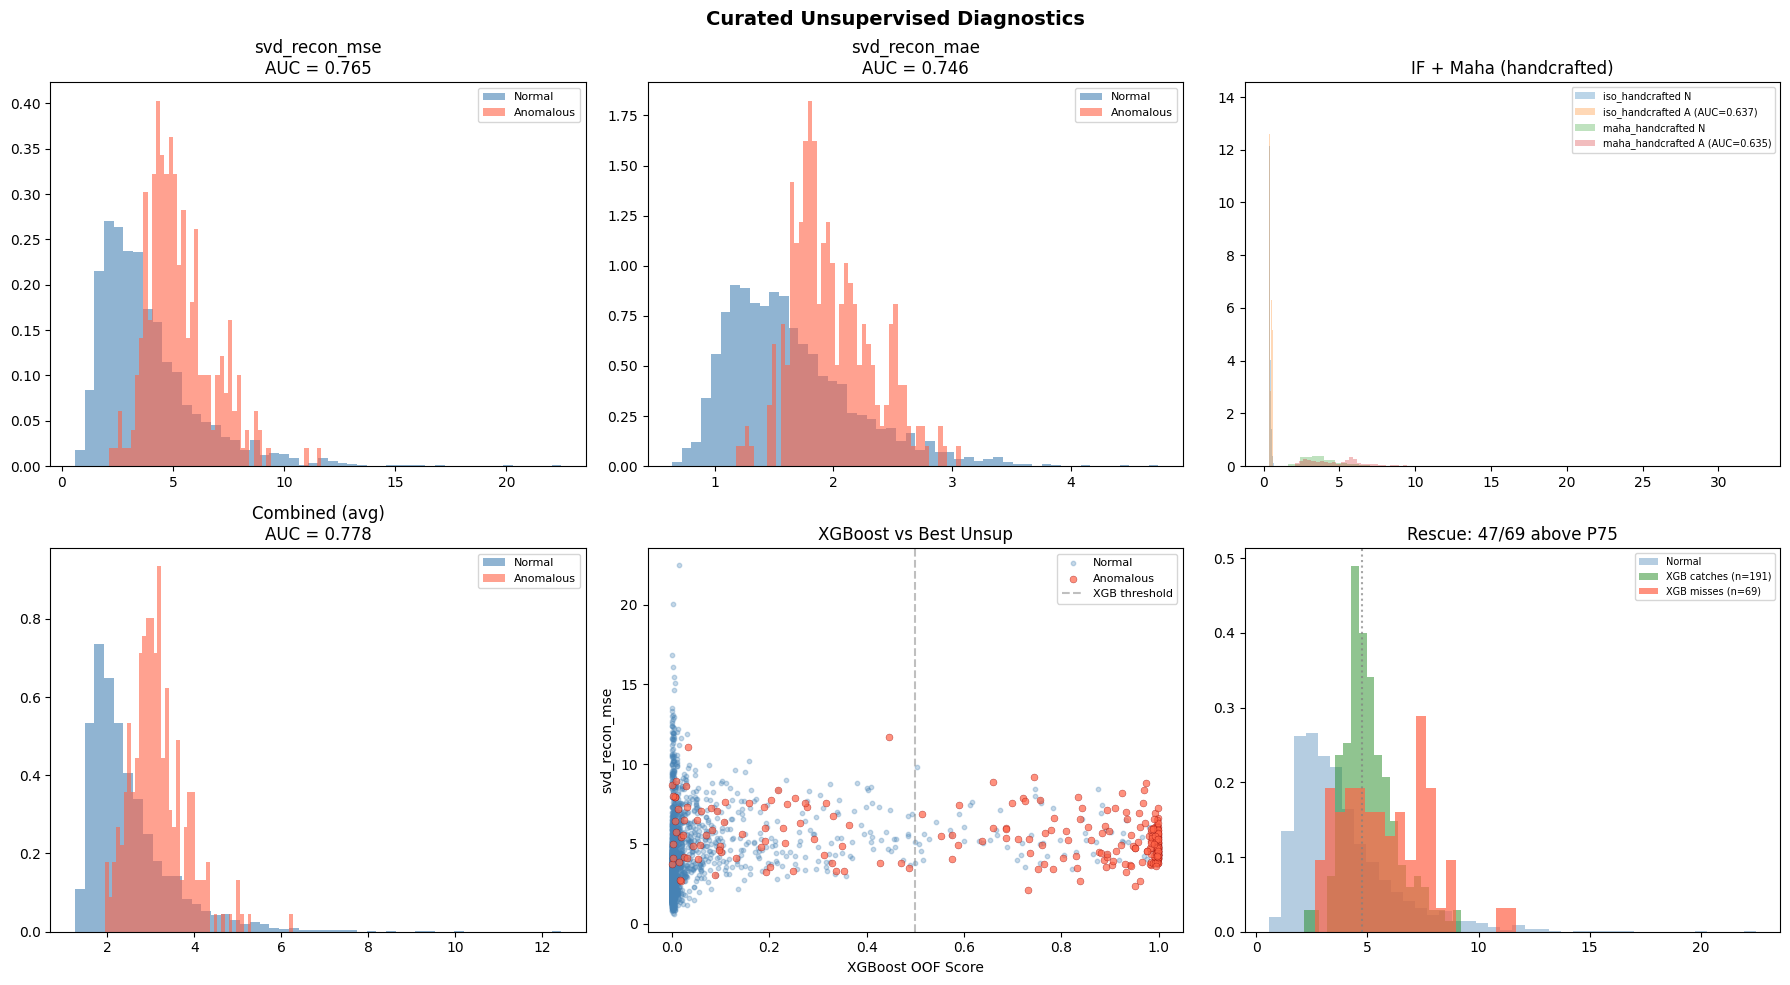


── Per-score AUCs ─────────────────────────────────────
  svd_recon_mse             AUC = 0.765
  svd_recon_mae             AUC = 0.746
  iso_handcrafted           AUC = 0.637
  maha_handcrafted          AUC = 0.635
  combined                  AUC = 0.778

XGBoost OOF AUC: 0.962
Missed: 69/260
  rescuable: 47/69
→ Moderate. BLEND_ALPHA = 0.15–0.25


In [19]:
# ── Unsupervised Score Diagnostics ────────────────────────────────────

unsup_idxs = [feature_cols_all.index(c) for c in UNSUP_COLS]
unsup_matrix = X_trainval_s[:, unsup_idxs]

labels_bool = y_trainval.astype(bool)
normal_mask = ~labels_bool
anom_mask   = labels_bool

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Curated Unsupervised Diagnostics", fontsize=14, fontweight="bold")

# Row 1: per-score distributions
for i, (ax, name) in enumerate(zip(axes[0], UNSUP_COLS[:3])):
    vals_n = unsup_matrix[normal_mask, i]
    vals_a = unsup_matrix[anom_mask, i]
    ax.hist(vals_n, bins=50, alpha=0.6, label="Normal", density=True, color="steelblue")
    ax.hist(vals_a, bins=50, alpha=0.6, label="Anomalous", density=True, color="tomato")
    auc_i = roc_auc_score(y_trainval, unsup_matrix[:, i])
    ax.set_title(f"{name}\nAUC = {auc_i:.3f}")
    ax.legend(fontsize=8)

# Row 1, slot 3: 4th score if exists
if len(UNSUP_COLS) > 3:
    ax = axes[0][2]
    ax.clear()
    for i in [2, 3]:
        vals_a = unsup_matrix[anom_mask, i]
        vals_n = unsup_matrix[normal_mask, i]
        auc_i = roc_auc_score(y_trainval, unsup_matrix[:, i])
        ax.hist(vals_n, bins=40, alpha=0.3, density=True, label=f"{UNSUP_COLS[i]} N")
        ax.hist(vals_a, bins=40, alpha=0.3, density=True, label=f"{UNSUP_COLS[i]} A (AUC={auc_i:.3f})")
    ax.set_title("IF + Maha (handcrafted)")
    ax.legend(fontsize=7)

# Row 2, Left: combined
ax = axes[1][0]
combined = unsup_matrix.mean(axis=1)
ax.hist(combined[normal_mask], bins=50, alpha=0.6, label="Normal", density=True, color="steelblue")
ax.hist(combined[anom_mask], bins=50, alpha=0.6, label="Anomalous", density=True, color="tomato")
auc_combined = roc_auc_score(y_trainval, combined)
ax.set_title(f"Combined (avg)\nAUC = {auc_combined:.3f}")
ax.legend(fontsize=8)

# Row 2, Middle: XGBoost vs best unsupervised
ax = axes[1][1]
unsup_aucs = [roc_auc_score(y_trainval, unsup_matrix[:, i]) for i in range(unsup_matrix.shape[1])]
best_idx = np.argmax(unsup_aucs)
best_unsup = unsup_matrix[:, best_idx]
ax.scatter(oof_scores[normal_mask], best_unsup[normal_mask], alpha=0.3, s=10, c="steelblue", label="Normal")
ax.scatter(oof_scores[anom_mask], best_unsup[anom_mask], alpha=0.7, s=25, c="tomato", label="Anomalous",
           edgecolors="darkred", linewidths=0.3)
ax.axvline(0.5, color="gray", ls="--", alpha=0.5, label="XGB threshold")
ax.set_xlabel("XGBoost OOF Score")
ax.set_ylabel(f"{UNSUP_COLS[best_idx]}")
ax.set_title("XGBoost vs Best Unsup")
ax.legend(fontsize=8)

# Row 2, Right: rescue
ax = axes[1][2]
xgb_missed = anom_mask & (oof_scores < 0.5)
n_missed = xgb_missed.sum()
n_caught = (anom_mask & (oof_scores >= 0.5)).sum()
if n_missed > 0:
    unsup_missed = best_unsup[xgb_missed]
    unsup_normal = best_unsup[normal_mask]
    p75 = np.percentile(unsup_normal, 75)
    rescuable = (unsup_missed > p75).sum()
    ax.hist(unsup_normal, bins=40, alpha=0.4, density=True, color="steelblue", label="Normal")
    ax.hist(best_unsup[anom_mask & (oof_scores >= 0.5)], bins=20, alpha=0.5, density=True, color="forestgreen", label=f"XGB catches (n={n_caught})")
    ax.hist(unsup_missed, bins=20, alpha=0.7, density=True, color="tomato", label=f"XGB misses (n={n_missed})")
    ax.axvline(p75, color="gray", ls=":", alpha=0.7)
    ax.set_title(f"Rescue: {rescuable}/{n_missed} above P75")
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

print("\n── Per-score AUCs ─────────────────────────────────────")
for name, auc in zip(UNSUP_COLS, unsup_aucs):
    print(f"  {name:25s} AUC = {auc:.3f}")
print(f"  {"combined":25s} AUC = {auc_combined:.3f}")
print(f"\nXGBoost OOF AUC: {roc_auc_score(y_trainval, oof_scores):.3f}")
print(f"Missed: {n_missed}/{anom_mask.sum()}")
if n_missed > 0:
    print(f"  rescuable: {rescuable}/{n_missed}")
if auc_combined > 0.85 and n_missed > 0 and rescuable / max(n_missed, 1) > 0.4:
    print("→ Strong. BLEND_ALPHA = 0.25–0.35")
elif auc_combined > 0.75 and n_missed > 0 and rescuable / max(n_missed, 1) > 0.2:
    print("→ Moderate. BLEND_ALPHA = 0.15–0.25")
else:
    print("→ Weak. BLEND_ALPHA = 0.10–0.15 or disable.")


#### **Model Predictions**

In [20]:
# Load test data
XX_test, _ = load_npz("data/third_batch.npz")

In [21]:
# ── Test predictions ──────────────────────────────────────────────────
fold_test_preds = []

for fold_id, art in enumerate(fold_artifacts, 1):
    model           = art["model"]
    item_stats_fold = art["item_stats"]
    feat_cols_fold  = art["feature_cols"]
    scaler_fold     = art["scaler"]
    normal_users_fold = art["normal_users"]

    # Handcrafted + structural features for test
    test_df = build_all_features(XX_test, item_stats_fold)
    hc_cols_fold = [c for c in feat_cols_fold if c not in UNSUP_COLS]

    for c in hc_cols_fold:
        if c not in test_df.columns:
            test_df[c] = 0.0

    X_test_hc_s = scaler_fold.transform(test_df[hc_cols_fold].values)

    # Unsupervised scores for test
    # Reference = full training set (handcrafted, scaled with this fold's scaler)
    ref_df = build_all_features(XX_all, item_stats_fold)
    for c in hc_cols_fold:
        if c not in ref_df.columns:
            ref_df[c] = 0.0
    X_ref_hc_s = scaler_fold.transform(ref_df[hc_cols_fold].values)
    ref_labels = ref_df.merge(yy_all, on="user", how="left")["label"].values

    unsup_test, _ = build_unsupervised_scores(
        XX_ref=XX_all, XX_target=XX_test,
        target_users=test_df["user"].values,
        ref_normal_users=normal_users_fold,
        X_handcrafted_ref=X_ref_hc_s,
        X_handcrafted_target=X_test_hc_s,
        ref_labels=ref_labels,
    )

    X_test_final = np.hstack([X_test_hc_s, unsup_test])
    p_test = model.predict_proba(X_test_final)[:, 1]
    fold_test_preds.append(p_test)
    print(f"Generated test predictions from fold {fold_id:02d}")

fold_test_preds = np.column_stack(fold_test_preds)
y_score_raw = fold_test_preds.mean(axis=1)

# ── Standalone unsupervised blend (SVD recon MSE only) ────────────
# SVD recon MSE was the best standalone score (AUC=0.765),
# so use only that column for blending.
unsup_blend, _ = build_unsupervised_scores(
    XX_ref=XX_all, XX_target=XX_test,
    target_users=build_all_features(XX_test, item_stats_full)["user"].values,
    ref_normal_users=normal_users_all,
    X_handcrafted_ref=X_hc_s,
    X_handcrafted_target=scaler.transform(
        build_all_features(XX_test, item_stats_full)
        .reindex(columns=hc_cols, fill_value=0).values
    ),
    ref_labels=y_trainval,
)
# Column 0 = svd_recon_mse
recon_mse_standalone = unsup_blend[:, 0]
recon_norm = (recon_mse_standalone - recon_mse_standalone.min()) / (
    recon_mse_standalone.max() - recon_mse_standalone.min() + 1e-9
)

print(f"\nXGBoost raw range:  [{y_score_raw.min():.4f}, {y_score_raw.max():.4f}]")
print(f"SVD recon range:    [{recon_norm.min():.4f}, {recon_norm.max():.4f}]")

BLEND_ALPHA = 0.15  # conservative — SVD recon MSE is the only trusted signal
y_blended = (1 - BLEND_ALPHA) * y_score_raw + BLEND_ALPHA * recon_norm

y_score_cal = calibrator.predict_proba(y_blended.reshape(-1, 1))[:, 1]
y_score_norm = (y_score_cal - y_score_cal.min()) / (
    y_score_cal.max() - y_score_cal.min() + 1e-9
)

print(f"\nFinal shape: {y_score_norm.shape}")
print(f"Final range: [{y_score_norm.min():.4f}, {y_score_norm.max():.4f}]")


Generated test predictions from fold 01
Generated test predictions from fold 02
Generated test predictions from fold 03
Generated test predictions from fold 04
Generated test predictions from fold 05

XGBoost raw range:  [0.0000, 0.9993]
SVD recon range:    [0.0000, 1.0000]

Final shape: (1625,)
Final range: [0.0000, 1.0000]


#### **Evaluation (local/Codabench)**

In [22]:
# Save submission
np.savez("submission.npz", predictions=y_score_norm)
with zipfile.ZipFile("submission.zip", "w", zipfile.ZIP_DEFLATED) as zf:
    zf.write("submission.npz", arcname="submission.npz")
pd.DataFrame({"predictions": y_score_norm}).to_csv("submission.csv", index=False)
print("submission.zip ready for Codabench")

submission.zip ready for Codabench


# **XGBoost_w_unsup_scores2.zip**
AUC:       0.8817
Precision: 0.7105
Recall:    0.4320
F1 Score:  0.5373